# Simple SD 1.5 + LoRA (eye diseases)

**Important:** After running the install cell, do **Runtime → Restart session**, then run from the paths cell onward. Do not re-run the install cell after restart.

## 0. Install (run once, then RESTART SESSION)

In [1]:
# Do NOT pin/downgrade numpy. Kaggle already has numpy 2.x;
# changing it without a full restart breaks pandas/scipy C extensions.
import subprocess, sys

pkgs = [
    "diffusers==0.30.0",
    "transformers==4.44.2",
    "accelerate==1.0.1",   # supports numpy 2.x (0.33 required numpy<2)
    "peft==0.13.2",
    "safetensors",
]
subprocess.run([sys.executable, "-m", "pip", "install", "-q", *pkgs], check=True)

import numpy as np, torch
print("numpy:", np.__version__)
print("torch:", torch.__version__, "| CUDA:", torch.cuda.is_available(), "| GPUs:", torch.cuda.device_count())
for i in range(torch.cuda.device_count()):
    print(f"  GPU {i}:", torch.cuda.get_device_name(i))

print("\n>>> NOW: Runtime → Restart session, then skip this cell and continue from the next one.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 63.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 104.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 330.9/330.9 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 320.7/320.7 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 26.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 97.4 MB/s eta 0:00:00
numpy: 2.0.2
torch: 2.10.0+cu128 | CUDA: True | GPUs: 2
  GPU 0: Tesla T4
  GPU 1: Tesla T4

>>> NOW: Runtime → Restart session, then skip this cell and continue from the next one.


In [2]:
!pip install -q "torchao>=0.16.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 79.7 MB/s eta 0:00:00:00:01


## 1. Paths & config  (start here AFTER restart)

In [3]:
import os, random, glob
import numpy as np
import pandas as pd
import torch
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T

print("numpy", np.__version__, "| torch", torch.__version__)

CSV_CANDIDATES = [
    "/kaggle/input/pilot-meta/prompt_meta.csv",
    "/kaggle/input/datasets/sblab04/pilot-meta/prompt_meta.csv",
]
IMAGE_CANDIDATES = [
    "/kaggle/input/eye-diseases-classification/dataset",
    "/kaggle/input/datasets/fahadhasan93/eye-diseases-classification/dataset",
]

def first_existing(paths):
    for p in paths:
        if os.path.exists(p):
            return p
    raise FileNotFoundError(paths)

CSV_PATH = first_existing(CSV_CANDIDATES)
IMAGE_ROOT = first_existing(IMAGE_CANDIDATES)

OUTPUT_DIR = "/kaggle/working/outputs/A_baseline"
GEN_DIR = "/kaggle/working/generated/A_baseline"
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(GEN_DIR, exist_ok=True)

RESOLUTION = 512
BATCH_SIZE = 2
GRAD_ACCUM = 4
LR = 1e-4
NUM_EPOCHS = 3
MAX_TRAIN_STEPS = None   # e.g. 100 for a quick smoke test
SEED = 47
LORA_RANK = 8
PRETRAINED = "runwayml/stable-diffusion-v1-5"

print("CSV:", CSV_PATH)
print("Images:", IMAGE_ROOT)

numpy 2.0.2 | torch 2.10.0+cu128
CSV: /kaggle/input/datasets/sblab04/pilot-meta/prompt_meta.csv
Images: /kaggle/input/datasets/fahadhasan93/eye-diseases-classification/dataset


## 2. Dataset

In [4]:
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

df = pd.read_csv(CSV_PATH)
print("columns:", list(df.columns), "| rows:", len(df))

colmap = {}
for c in df.columns:
    cl = c.lower().strip()
    if cl in ("image name", "image_name", "filename", "file_name", "image"):
        colmap[c] = "image_name"
    elif cl in ("class", "label"):
        colmap[c] = "class"
    elif cl in ("prompt", "prompt_tr", "text", "caption"):
        colmap[c] = "prompt"
df = df.rename(columns=colmap)
assert {"image_name", "class", "prompt"}.issubset(df.columns), list(df.columns)

print(df["class"].value_counts())

def resolve_image(name):
    direct = os.path.join(IMAGE_ROOT, name)
    if os.path.exists(direct):
        return direct
    for root, _, files in os.walk(IMAGE_ROOT):
        if name in files:
            return os.path.join(root, name)
    raise FileNotFoundError(name)

print("path check:", resolve_image(str(df.iloc[0]["image_name"])))

transform = T.Compose([
    T.Resize((RESOLUTION, RESOLUTION)),
    T.ToTensor(),
    T.Normalize([0.5], [0.5]),
])

class EyeDataset(Dataset):
    def __init__(self, dataframe):
        self.df = dataframe.reset_index(drop=True)
    def __len__(self):
        return len(self.df)
    def __getitem__(self, i):
        row = self.df.iloc[i]
        img = Image.open(resolve_image(str(row["image_name"]))).convert("RGB")
        return {"image": transform(img), "prompt": str(row["prompt"]), "class": str(row["class"])}

idx = np.random.permutation(len(df))
n_val = max(1, int(0.05 * len(df)))
train_ds = EyeDataset(df.iloc[idx[n_val:]])
val_ds = EyeDataset(df.iloc[idx[:n_val]])
classes = sorted(df["class"].unique().tolist())
print(f"train={len(train_ds)} val={len(val_ds)} classes={classes}")

columns: ['Image name', 'Class', 'prompt_tr'] | rows: 4217
class
diabetic_retinopathy    1098
normal                  1074
cataract                1038
glaucoma                1007
Name: count, dtype: int64
path check: /kaggle/input/datasets/fahadhasan93/eye-diseases-classification/dataset/cataract/0_left.jpg
train=4007 val=210 classes=['cataract', 'diabetic_retinopathy', 'glaucoma', 'normal']


## 3. Load SD 1.5 + LoRA

In [5]:
from diffusers import AutoencoderKL, DDPMScheduler, UNet2DConditionModel
from transformers import CLIPTextModel, CLIPTokenizer
from peft import LoraConfig

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# VAE + text encoder in fp16 to save VRAM; UNet stays fp32 for stable LoRA training
weight_dtype = torch.float16

tokenizer = CLIPTokenizer.from_pretrained(PRETRAINED, subfolder="tokenizer")
text_encoder = CLIPTextModel.from_pretrained(PRETRAINED, subfolder="text_encoder")
vae = AutoencoderKL.from_pretrained(PRETRAINED, subfolder="vae")
unet = UNet2DConditionModel.from_pretrained(PRETRAINED, subfolder="unet")
noise_scheduler = DDPMScheduler.from_pretrained(PRETRAINED, subfolder="scheduler")

text_encoder.requires_grad_(False)
vae.requires_grad_(False)
unet.requires_grad_(False)

text_encoder.to(device, dtype=weight_dtype)
vae.to(device, dtype=weight_dtype)
unet.to(device)  # fp32

unet.add_adapter(LoraConfig(
    r=LORA_RANK, lora_alpha=16, lora_dropout=0.05,
    target_modules=["to_q", "to_k", "to_v", "to_out.0"],
))

trainable = [p for p in unet.parameters() if p.requires_grad]
print(f"Trainable params: {sum(p.numel() for p in trainable):,}")
print(f"UNet dtype: {next(unet.parameters()).dtype} | VAE dtype: {next(vae.parameters()).dtype}")

optimizer = torch.optim.AdamW(trainable, lr=LR)
scaler = torch.cuda.amp.GradScaler(enabled=True)


The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

tokenizer_config.json:   0%|          | 0.00/806 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

unet/diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

scheduler_config.json:   0%|          | 0.00/308 [00:00<?, ?B/s]

Trainable params: 1,594,368
UNet dtype: torch.float32 | VAE dtype: torch.float16


/tmp/ipykernel_58/2255300785.py:33: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=True)


## 4. One-batch sanity check

In [6]:
sample = train_ds[0]
img = sample["image"].unsqueeze(0).to(device, dtype=weight_dtype)
tok = tokenizer([sample["prompt"]], padding="max_length", truncation=True,
                max_length=tokenizer.model_max_length, return_tensors="pt").to(device)

with torch.no_grad():
    latents = vae.encode(img).latent_dist.sample() * vae.config.scaling_factor
    emb = text_encoder(tok.input_ids)[0]
print("latents", tuple(latents.shape), latents.dtype, "| emb", tuple(emb.shape), emb.dtype)

# UNet is fp32 — cast inputs up to float32
latents = latents.to(dtype=torch.float32)
emb = emb.to(dtype=torch.float32)
noise = torch.randn_like(latents)
ts = torch.randint(0, noise_scheduler.config.num_train_timesteps, (1,), device=device).long()
noisy = noise_scheduler.add_noise(latents, noise, ts)

pred = unet(noisy, ts, encoder_hidden_states=emb).sample
loss = torch.nn.functional.mse_loss(pred.float(), noise.float())
loss.backward()
optimizer.step()
optimizer.zero_grad()
print(f"Sanity OK, loss={loss.item():.4f}")
torch.cuda.empty_cache()


latents (1, 4, 64, 64) torch.float16 | emb (1, 77, 768) torch.float16
Sanity OK, loss=0.0089


## 5. Train

In [7]:
def collate(batch):
    images = torch.stack([b["image"] for b in batch])
    prompts = [b["prompt"] for b in batch]
    tok = tokenizer(prompts, padding="max_length", truncation=True,
                    max_length=tokenizer.model_max_length, return_tensors="pt")
    return {"image": images, "input_ids": tok.input_ids}

loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                    num_workers=2, collate_fn=collate, drop_last=True)

unet.train()
global_step = 0

for epoch in range(1, NUM_EPOCHS + 1):
    running, n = 0.0, 0
    optimizer.zero_grad()
    for step, batch in enumerate(loader):
        images = batch["image"].to(device, dtype=weight_dtype)
        input_ids = batch["input_ids"].to(device)

        with torch.no_grad():
            latents = vae.encode(images).latent_dist.sample() * vae.config.scaling_factor
            emb = text_encoder(input_ids)[0]

        # match UNet fp32
        latents = latents.to(dtype=torch.float32)
        emb = emb.to(dtype=torch.float32)
        noise = torch.randn_like(latents)
        bsz = latents.shape[0]
        ts = torch.randint(0, noise_scheduler.config.num_train_timesteps, (bsz,), device=device).long()
        noisy = noise_scheduler.add_noise(latents, noise, ts)

        with torch.autocast("cuda", dtype=torch.float16):
            pred = unet(noisy, ts, encoder_hidden_states=emb).sample
            loss = torch.nn.functional.mse_loss(pred.float(), noise.float()) / GRAD_ACCUM

        scaler.scale(loss).backward()

        if (step + 1) % GRAD_ACCUM == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(trainable, 1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()
            global_step += 1

        running += loss.item() * GRAD_ACCUM
        n += 1
        if step % 20 == 0:
            print(f"epoch {epoch}/{NUM_EPOCHS} step {step}/{len(loader)} loss={loss.item()*GRAD_ACCUM:.4f}")

        if MAX_TRAIN_STEPS is not None and global_step >= MAX_TRAIN_STEPS:
            break

    print(f"=== epoch {epoch} avg_loss={running/max(1,n):.4f} step={global_step} ===")
    ckpt = os.path.join(OUTPUT_DIR, f"lora_epoch{epoch}")
    unet.save_pretrained(ckpt)
    print("saved", ckpt)

    if MAX_TRAIN_STEPS is not None and global_step >= MAX_TRAIN_STEPS:
        break

print("Training finished.")


epoch 1/3 step 0/2003 loss=0.0240
epoch 1/3 step 20/2003 loss=0.1044
epoch 1/3 step 40/2003 loss=0.1405
epoch 1/3 step 60/2003 loss=0.0145
epoch 1/3 step 80/2003 loss=0.0125
epoch 1/3 step 100/2003 loss=0.2915
epoch 1/3 step 120/2003 loss=0.0642
epoch 1/3 step 140/2003 loss=0.0049
epoch 1/3 step 160/2003 loss=0.1660
epoch 1/3 step 180/2003 loss=0.0460
epoch 1/3 step 200/2003 loss=0.1414
epoch 1/3 step 220/2003 loss=0.0048
epoch 1/3 step 240/2003 loss=0.0084
epoch 1/3 step 260/2003 loss=0.2372
epoch 1/3 step 280/2003 loss=0.0354
epoch 1/3 step 300/2003 loss=0.0354
epoch 1/3 step 320/2003 loss=0.0469
epoch 1/3 step 340/2003 loss=0.0669
epoch 1/3 step 360/2003 loss=0.0031
epoch 1/3 step 380/2003 loss=0.0474
epoch 1/3 step 400/2003 loss=0.0444
epoch 1/3 step 420/2003 loss=0.0401
epoch 1/3 step 440/2003 loss=0.2788
epoch 1/3 step 460/2003 loss=0.3630
epoch 1/3 step 480/2003 loss=0.0286
epoch 1/3 step 500/2003 loss=0.0783
epoch 1/3 step 520/2003 loss=0.3816
epoch 1/3 step 540/2003 loss=0.125

## 6. Generate

In [8]:
from diffusers import StableDiffusionPipeline

print("Building pipeline for generation (all components float16)...")

# Inference: put UNet (+ LoRA) into float16 so it matches VAE/text encoder
unet.eval()
unet.to(device, dtype=torch.float16)

pipe = StableDiffusionPipeline(
    vae=vae,
    text_encoder=text_encoder,
    tokenizer=tokenizer,
    unet=unet,
    scheduler=noise_scheduler,
    safety_checker=None,
    feature_extractor=None,
    requires_safety_checker=False,
)
pipe = pipe.to(device)
pipe.set_progress_bar_config(disable=False)

class_prompts = {c: str(df[df["class"] == c].iloc[0]["prompt"]) for c in classes}
for c, p in class_prompts.items():
    print(f"  {c}: {p[:90]}...")

SEEDS = [47, 133, 478]
for class_name, prompt in class_prompts.items():
    out_cls = os.path.join(GEN_DIR, class_name)
    os.makedirs(out_cls, exist_ok=True)
    for i, seed in enumerate(SEEDS):
        g = torch.Generator(device=device).manual_seed(seed)
        with torch.autocast("cuda", dtype=torch.float16):
            img = pipe(
                prompt,
                num_inference_steps=30,
                guidance_scale=7.5,
                generator=g,
            ).images[0]
        path = os.path.join(out_cls, f"sample_{i:02d}_seed{seed}.png")
        img.save(path)
        print("saved", path)

print("\nDone ->", GEN_DIR)


Building pipeline for generation (all components float16)...
  cataract: high quality fundus photograph of an eye with cataract, cloudy lens, reduced clarity, medi...
  diabetic_retinopathy: high quality fundus photograph of an eye with diabetic retinopathy, microaneurysms, hemorr...
  glaucoma: high quality fundus photograph of an eye with glaucoma, optic disc cupping, increased cup-...
  normal: high quality fundus photograph of a healthy normal eye, clear optic disc, healthy retinal ...


  0%|          | 0/30 [00:00<?, ?it/s]

saved /kaggle/working/generated/A_baseline/cataract/sample_00_seed47.png


  0%|          | 0/30 [00:00<?, ?it/s]

saved /kaggle/working/generated/A_baseline/cataract/sample_01_seed133.png


...

saved /kaggle/working/generated/A_baseline/normal/sample_00_seed47.png


  0%|          | 0/30 [00:00<?, ?it/s]

saved /kaggle/working/generated/A_baseline/normal/sample_01_seed133.png


  0%|          | 0/30 [00:00<?, ?it/s]

saved /kaggle/working/generated/A_baseline/normal/sample_02_seed478.png

Done -> /kaggle/working/generated/A_baseline


## 7. Preview

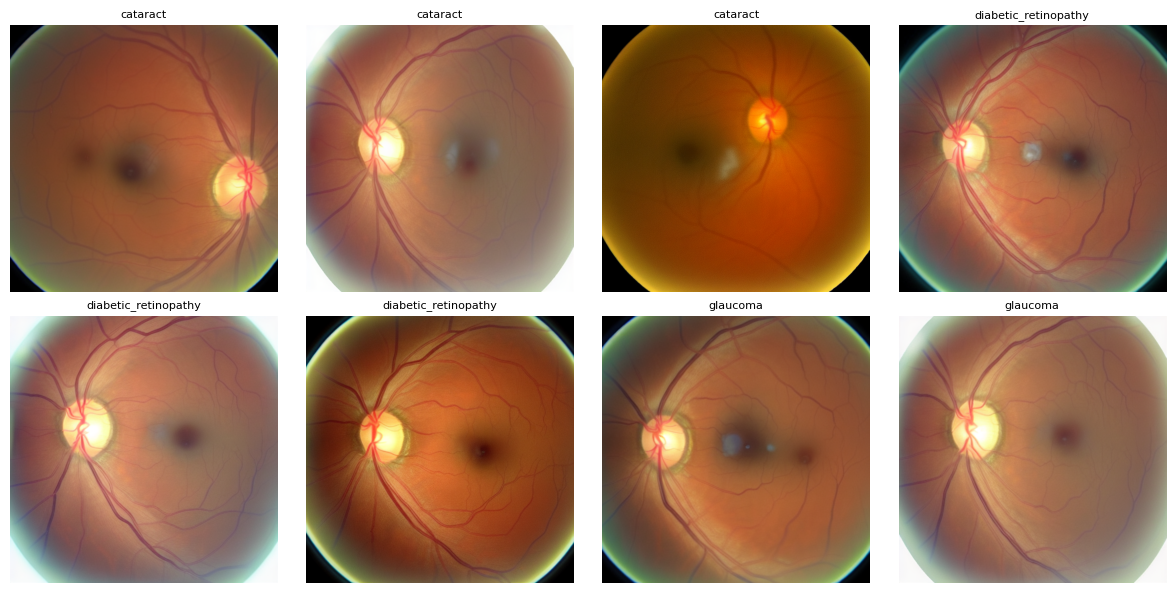

In [9]:
import matplotlib.pyplot as plt

paths = sorted(glob.glob(os.path.join(GEN_DIR, "*", "*.png")))[:8]
if not paths:
    print("No images yet")
else:
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    for ax, p in zip(axes.flatten(), paths):
        ax.imshow(Image.open(p))
        ax.set_title(os.path.basename(os.path.dirname(p))[:24], fontsize=8)
        ax.axis("off")
    for ax in axes.flatten()[len(paths):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()